In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)

import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Ready.")

Ready.


In [31]:
if "google.colab" in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
else:
    FILENAME = "ftse250_clustering_ready.csv"
print("Using file:", FILENAME)

Saving ftse250_clustering_ready.csv to ftse250_clustering_ready.csv
Using file: ftse250_clustering_ready.csv


In [32]:
MAX_MISSING_FRAC = 0.10

df = pd.read_csv(FILENAME)
date_cols = [c for c in df.columns if c != "Ticker"]

frac = df[date_cols].isna().sum(axis=1) / len(date_cols)
dropped = df.loc[frac > MAX_MISSING_FRAC, "Ticker"].tolist()
df = df.loc[frac <= MAX_MISSING_FRAC].reset_index(drop=True)

n_filled = int(df[date_cols].isna().sum().sum())
df[date_cols] = df[date_cols].ffill(axis=1).bfill(axis=1)

tickers = df["Ticker"].values
A = df[date_cols].values.astype(float)
dates = pd.to_datetime(date_cols)

print(f"Dropped (>10% missing) : {len(dropped)} {dropped}")
print(f"Single gaps filled     : {n_filled}")
print(f"Stocks retained        : {len(df)}")
print(f"Trading days           : {len(date_cols)}")
print(f"Date range             : {date_cols[0]} to {date_cols[-1]}")
assert df[date_cols].isna().sum().sum() == 0

Dropped (>10% missing) : 0 []
Single gaps filled     : 4
Stocks retained        : 241
Trading days           : 1153
Date range             : 2021-11-30 to 2026-06-29


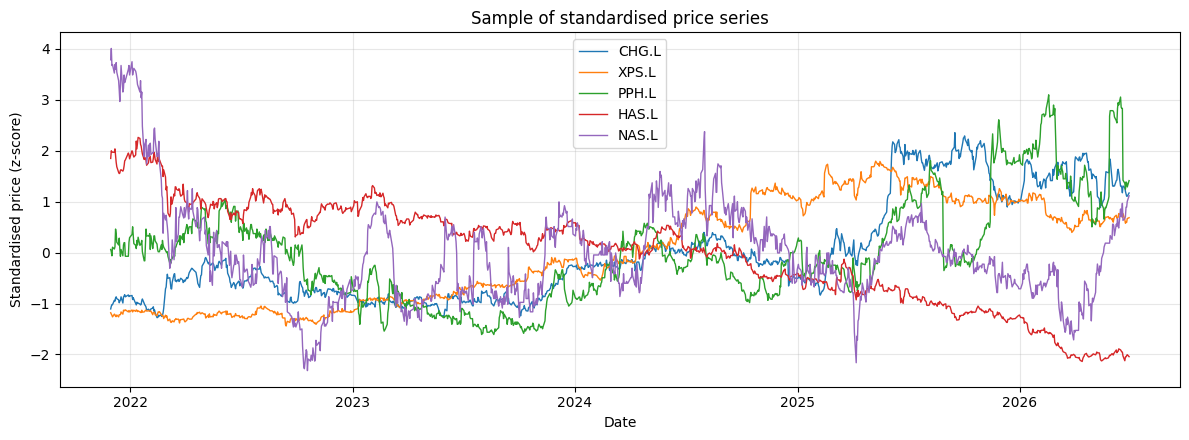

In [33]:
# Look at 5 random stocks
idx = np.random.default_rng(RANDOM_STATE).choice(len(tickers), 5, replace=False)
fig, ax = plt.subplots(figsize=(12, 4.5))
for i in idx:
    ax.plot(dates, A[i], linewidth=1, label=tickers[i])
ax.set_title("Sample of standardised price series")
ax.set_xlabel("Date"); ax.set_ylabel("Standardised price (z-score)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); plt.tight_layout(); plt.show()

In [34]:
USE_PCA = True
VARIANCE_TARGET = 0.90

if USE_PCA:
    pca = PCA(n_components=VARIANCE_TARGET, random_state=RANDOM_STATE)
    X = pca.fit_transform(A)
    print(f"PCA: {A.shape[1]} days -> {X.shape[1]} components "
          f"({VARIANCE_TARGET:.0%} of variance)")
    print(f"PC1 alone explains {pca.explained_variance_ratio_[0]*100:.1f}% "
          f"(this is the common market factor)")
else:
    X = A
    print(f"No PCA: clustering raw {X.shape[1]} dimensions")

print("Clustering matrix:", X.shape)

PCA: 1153 days -> 9 components (90% of variance)
PC1 alone explains 48.0% (this is the common market factor)
Clustering matrix: (241, 9)


In [35]:
K_RANGE = range(2, 11)
N_BOOTSTRAP = 50
STABILITY_FLOOR = 0.60


def bootstrap_stability(X, k, B=N_BOOTSTRAP, frac=0.8, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n, m = X.shape[0], int(0.8 * X.shape[0])
    idxs, labs = [], []
    for b in range(B):
        i = rng.choice(n, m, replace=False)
        idxs.append(i)
        labs.append(KMeans(k, n_init=5, random_state=seed + b).fit_predict(X[i]))
    maps = [dict(zip(i, l)) for i, l in zip(idxs, labs)]
    aris = []
    for i in range(B):
        for j in range(i + 1, B):
            common = np.intersect1d(idxs[i], idxs[j])
            if len(common) < 10:
                continue
            aris.append(adjusted_rand_score([maps[i][c] for c in common],
                                            [maps[j][c] for c in common]))
    return float(np.mean(aris)), float(np.min(aris))


def gap_statistic(X, k_range=K_RANGE, B=10, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    Xp = Xc @ Vt.T
    lo, hi = Xp.min(axis=0), Xp.max(axis=0)
    gaps, sks = [], []
    for k in k_range:
        logw = np.log(KMeans(k, n_init=5, random_state=seed).fit(X).inertia_)
        refs = [np.log(KMeans(k, n_init=5, random_state=seed + b)
                       .fit(rng.uniform(lo, hi, size=Xp.shape) @ Vt + X.mean(axis=0)).inertia_)
                for b in range(B)]
        refs = np.array(refs)
        gaps.append(refs.mean() - logw)
        sks.append(refs.std() * np.sqrt(1 + 1 / B))
    gaps, sks, ks = np.array(gaps), np.array(sks), list(k_range)
    choice = next((ks[i] for i in range(len(ks) - 1)
                   if gaps[i] >= gaps[i + 1] - sks[i + 1]), ks[int(np.argmax(gaps))])
    return gaps, choice


print("Functions defined.")

Functions defined.


In [36]:
t0 = time.time()
rows = []
for k in K_RANGE:
    lab = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
    stab, stab_min = bootstrap_stability(X, k)
    rows.append({
        "k": k,
        "silhouette": silhouette_score(X, lab),
        "calinski": calinski_harabasz_score(X, lab),
        "davies_bouldin": davies_bouldin_score(X, lab),
        "stability": stab,
        "stability_min": stab_min,
        "smallest_cluster": int(np.bincount(lab, minlength=k).min()),
    })

metrics = pd.DataFrame(rows)
gaps, gap_k = gap_statistic(X)
metrics["gap"] = gaps

print(f"Computed in {time.time()-t0:.0f}s\n")
display(metrics.round(4))

Computed in 21s



,k,silhouette,calinski,davies_bouldin,stability,stability_min,smallest_cluster,gap
0,2,0.3745,175.2400,1.1184,0.9487,0.7107,111,0.7054
1,3,0.2854,126.5068,1.3995,0.6331,0.2717,56,0.7588
2,4,0.2888,115.6018,1.2893,0.8031,0.4225,46,0.8416
3,5,0.2344,103.3873,1.3812,0.7804,0.3736,34,0.8719
4,6,0.2423,94.2368,1.4098,0.7004,0.3852,23,0.9071
5,7,0.2071,85.6944,1.4261,0.6204,0.3582,21,0.9162
6,8,0.1828,78.4358,1.4616,0.6006,0.3744,18,0.9093
7,9,0.1863,73.6242,1.4925,0.5835,0.3333,11,0.9298
8,10,0.1759,69.6627,1.4413,0.5629,0.3440,10,0.9458


In [37]:

metrics["r_sil"] = metrics["silhouette"].rank(ascending=False)
metrics["r_cal"] = metrics["calinski"].rank(ascending=False)
metrics["r_dav"] = metrics["davies_bouldin"].rank(ascending=True)
metrics["r_gap"] = metrics["gap"].rank(ascending=False)
metrics["r_sta"] = metrics["stability"].rank(ascending=False)
metrics["mean_rank"] = metrics[["r_sil", "r_cal", "r_dav", "r_gap", "r_sta"]].mean(axis=1)

admissible = metrics[metrics["stability"] >= STABILITY_FLOOR]
if len(admissible) == 0:
    print(f"WARNING: no k reaches the stability floor of {STABILITY_FLOOR}.")
    print("There is no reliable cluster structure in this representation.")
    admissible = metrics

consensus_k = int(admissible.sort_values("mean_rank").iloc[0]["k"])

print(f"Silhouette alone would pick k = {int(metrics.loc[metrics['silhouette'].idxmax(), 'k'])}")
print(f"Gap statistic picks         k = {gap_k}")
print(f"Consensus of all five       k = {consensus_k}")
print(f"\nStability at consensus k    : {float(metrics.loc[metrics['k']==consensus_k,'stability'].iloc[0]):.3f}")

Silhouette alone would pick k = 2
Gap statistic picks         k = 6
Consensus of all five       k = 2

Stability at consensus k    : 0.949


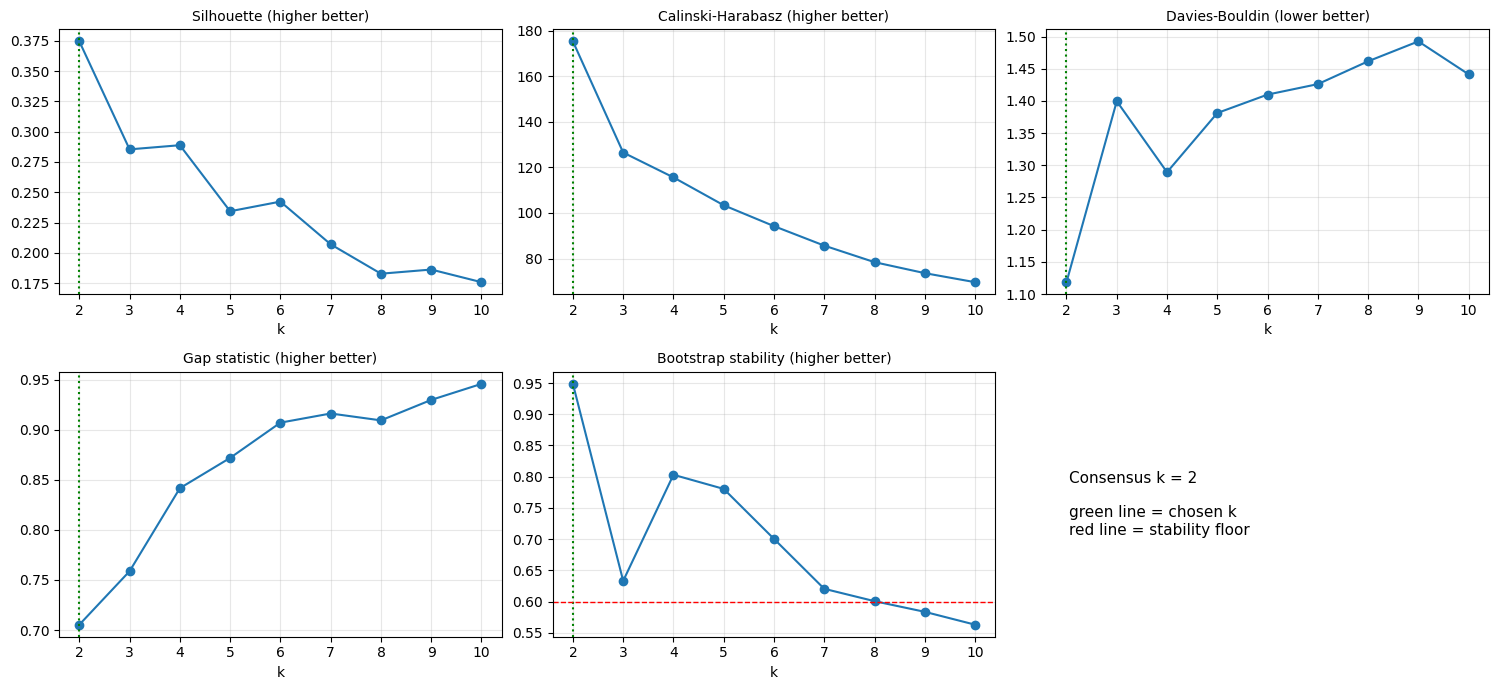

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
specs = [("silhouette", "Silhouette (higher better)"),
         ("calinski", "Calinski-Harabasz (higher better)"),
         ("davies_bouldin", "Davies-Bouldin (lower better)"),
         ("gap", "Gap statistic (higher better)"),
         ("stability", "Bootstrap stability (higher better)")]

for ax, (col, title) in zip(axes.flat, specs):
    ax.plot(metrics["k"], metrics[col], marker="o")
    ax.axvline(consensus_k, color="green", ls=":", lw=1.5)
    ax.set_title(title, fontsize=10); ax.set_xlabel("k")
    if col == "stability":
        ax.axhline(STABILITY_FLOOR, color="red", ls="--", lw=1)

axes.flat[5].axis("off")
axes.flat[5].text(0.05, 0.5, f"Consensus k = {consensus_k}\n\n"
                             f"green line = chosen k\nred line = stability floor",
                  fontsize=11, va="center")
plt.tight_layout(); plt.show()

In [39]:
FINAL_K = consensus_k

labels = KMeans(FINAL_K, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
stab, stab_min = bootstrap_stability(X, FINAL_K)

print("=" * 46)
print(f"  DATASET     : {FILENAME}")
print(f"  Stocks      : {len(tickers)}")
print(f"  Dimensions  : {X.shape[1]}" + ("  (PCA)" if USE_PCA else "  (raw)"))
print(f"  k           : {FINAL_K}")
print("-" * 46)
print(f"  Silhouette     : {silhouette_score(X, labels):.4f}")
print(f"  Calinski-H     : {calinski_harabasz_score(X, labels):.1f}")
print(f"  Davies-Bouldin : {davies_bouldin_score(X, labels):.4f}")
print(f"  Stability      : {stab:.4f}  (worst pair {stab_min:.3f})")
print("-" * 46)
print(f"  Cluster sizes  : {np.bincount(labels).tolist()}")
print("=" * 46)

  DATASET     : ftse250_clustering_ready.csv
  Stocks      : 241
  Dimensions  : 9  (PCA)
  k           : 2
----------------------------------------------
  Silhouette     : 0.3745
  Calinski-H     : 175.2
  Davies-Bouldin : 1.1184
  Stability      : 0.9487  (worst pair 0.711)
----------------------------------------------
  Cluster sizes  : [130, 111]


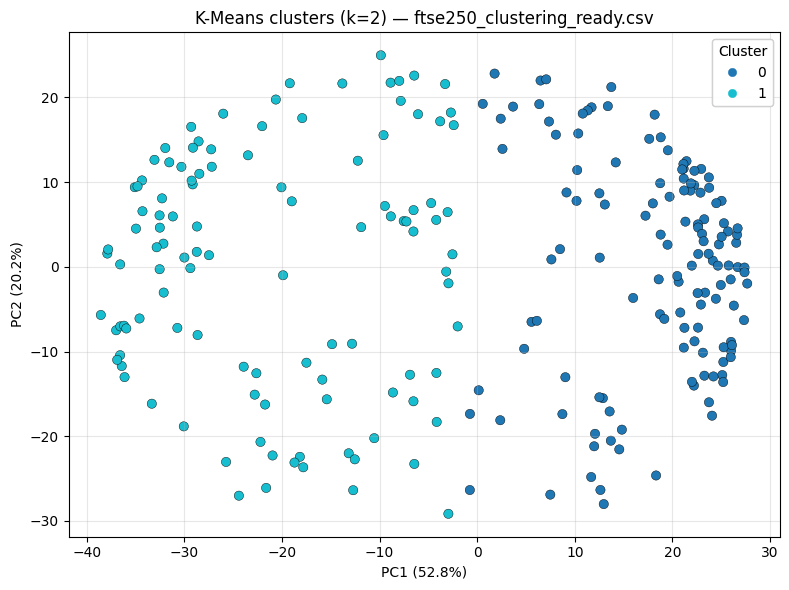

In [40]:

vis = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
V = vis.transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(V[:, 0], V[:, 1], c=labels, cmap="tab10", s=45, edgecolor="k", linewidth=0.3)
ax.set_title(f"K-Means clusters (k={FINAL_K}) — {FILENAME}")
ax.set_xlabel(f"PC1 ({vis.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({vis.explained_variance_ratio_[1]*100:.1f}%)")
ax.add_artist(ax.legend(*sc.legend_elements(), title="Cluster", loc="best"))
plt.tight_layout(); plt.show()

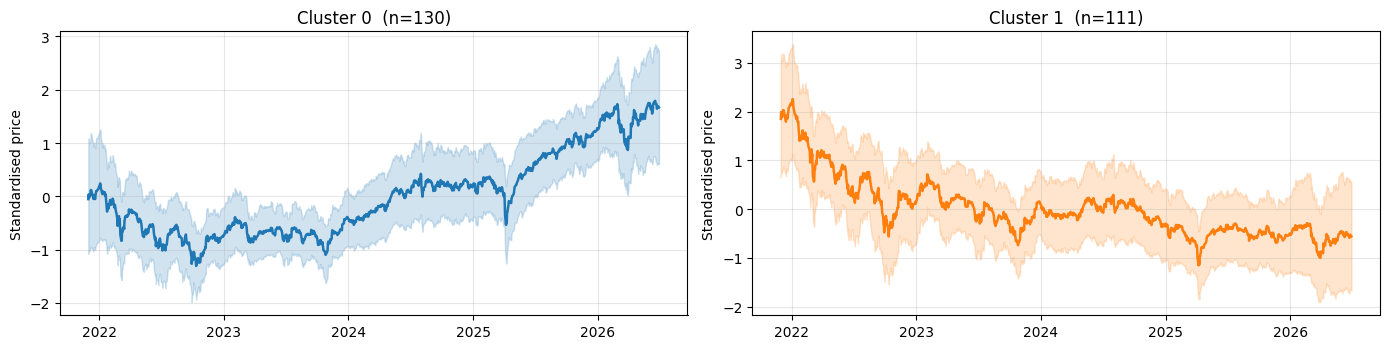

In [41]:

n_cols = 2
n_rows = int(np.ceil(FINAL_K / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), squeeze=False)

for c in range(FINAL_K):
    ax = axes[c // n_cols][c % n_cols]
    mem = A[labels == c]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(dates, mu, color=f"C{c}", lw=1.8)
    ax.fill_between(dates, mu - sd, mu + sd, color=f"C{c}", alpha=0.2)
    ax.set_title(f"Cluster {c}  (n={len(mem)})")
    ax.set_ylabel("Standardised price")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for c in range(FINAL_K, n_rows * n_cols):
    axes[c // n_cols][c % n_cols].axis("off")
plt.tight_layout(); plt.show()

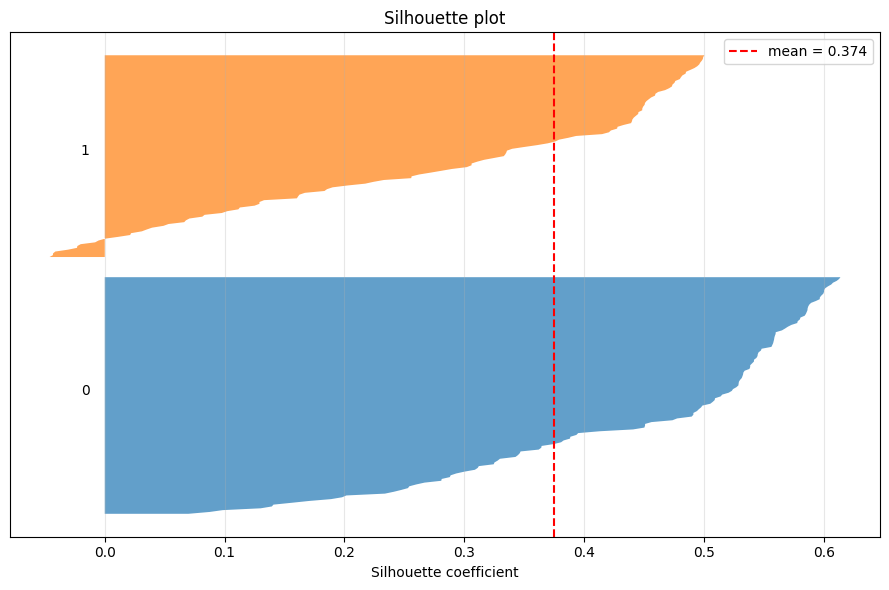

In [42]:

sv = silhouette_samples(X, labels)
fig, ax = plt.subplots(figsize=(9, 6))
y = 10
for c in range(FINAL_K):
    v = np.sort(sv[labels == c])
    ax.fill_betweenx(np.arange(y, y + len(v)), 0, v, facecolor=f"C{c}", alpha=0.7)
    ax.text(-0.02, y + 0.5 * len(v), str(c))
    y += len(v) + 10
ax.axvline(sv.mean(), color="red", ls="--", label=f"mean = {sv.mean():.3f}")
ax.set_title("Silhouette plot"); ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([]); ax.legend(); plt.tight_layout(); plt.show()

In [43]:
import textwrap
for c in range(FINAL_K):
    mem = sorted(tickers[labels == c])
    print(f"Cluster {c} (n={len(mem)}):")
    print(textwrap.fill(", ".join(mem), width=95))
    print()

Cluster 0 (n=130):
3IN.L, AAS.L, AEP.L, AGT.L, AIE.L, AJB.L, ALFA.L, AO.L, ASL.L, ATR.L, ATT.L, ATYM.L, AVON.L,
BAG.L, BBY.L, BCG.L, BGFD.L, BMY.L, BNKR.L, BOWL.L, BPCR.L, BRGE.L, BRWM.L, BUT.L, CHG.L,
CKN.L, CLDN.L, CMCX.L, COA.L, CORD.L, COST.L, CSN.L, CTY.L, CURY.L, CWK.L, DRX.L, EDIN.L,
ELM.L, ESCT.L, EWG.L, EWI.L, FAN.L, FCH.L, FCSS.L, FEML.L, FEV.L, FGP.L, FSG.L, FSV.L, GDWN.L,
GFRD.L, GNC.L, GSCT.L, HANA.L, HGT.L, HILS.L, HMSO.L, HOC.L, HRI.L, HTG.L, HTWS.L, HVPE.L,
HWG.L, IAD.L, ICGT.L, IPF.L, JAM.L, JCH.L, JEDT.L, JEGI.L, JEMI.L, JFJ.L, JGGI.L, JMGI.L,
JSG.L, JTC.L, KIE.L, KLR.L, LRE.L, LWDB.L, MAB.L, MEGP.L, MGNS.L, MNKS.L, MRC.L, MRCH.L, MTO.L,
MTRO.L, MUT.L, MYI.L, OCI.L, OSB.L, PAF.L, PAG.L, PCGH.L, PEY.L, PFD.L, PHI.L, PIN.L, PINT.L,
PLUS.L, PNL.L, POLN.L, PPET.L, PPH.L, QLT.L, QQ.L, RHIM.L, ROR.L, RTW.L, SAGA.L, SAIN.L, SCT.L,
SDP.L, SNR.L, SOI.L, SRP.L, TBCG.L, TCAP.L, TEM.L, TFIF.L, TMPL.L, TRST.L, UEM.L, USA.L,
VEIL.L, VSVS.L, WIX.L, WWH.L, XPS.L

Cluster 1 (n=111):
A

In [44]:
t_idx = np.arange(A.shape[1])
slopes = np.array([np.polyfit(t_idx, row, 1)[0] for row in A])
trend_sign = (slopes > 0).astype(int)

ari_trend = adjusted_rand_score(labels, trend_sign)
print(f"ARI between clusters and sign-of-trend: {ari_trend:.3f}")
print()
if ari_trend > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari_trend > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing something beyond trend direction.")

print(f"\nStocks trending up: {trend_sign.sum()} / down: {(1-trend_sign).sum()}")
print("\nMean slope per cluster:")
for c in range(FINAL_K):
    print(f"  Cluster {c}: {slopes[labels == c].mean():+.6f}")

ARI between clusters and sign-of-trend: 0.856

=> The clustering is largely a restatement of trend direction.

Stocks trending up: 139 / down: 102

Mean slope per cluster:
  Cluster 0: +0.001941
  Cluster 1: -0.001442
